In [33]:
import pandas as pd
import matplotlib.pyplot as plt
from aggregation import METHODS, get_conversion_factors
from scipy.interpolate import interp1d
# Load data from CSV file

def make_plot_for_country(country):

    train_data = pd.read_parquet("../data/{}/train.parquet".format(country))
    n_train = len(train_data)
    test_data = pd.read_parquet("../data/{}/test.parquet".format(country))
    n_test = len(test_data)
    n= n_train + n_test
    d = len(train_data.columns)

    conversion_factor = 1.0

    methods = METHODS.copy()
    conversion_factor = get_conversion_factors([country])[country]

    for method in METHODS:
        dic = methods[method]
        df = pd.read_csv('results/{}/{}.csv'.format(country, dic['csv']))
        dic['df'] = df
    fontsize = 20

    pre_transfer_poverty_gap = max(df['post_transfer_poverty_gap'])

    # Plot policy_cost_per_capita vs post_transfer_poverty_rate
    fig, ax = plt.subplots(1, 2, figsize=(20, 8))

    for method in methods:
        dic = methods[method]
        df = dic['df']

        ax[1].plot(df['post_transfer_poverty_rate'] * 100, df['policy_cost_per_capita'] * conversion_factor, marker='o', label=dic['name'], color=dic['color'], linestyle=dic['linestyle'])
        rate_interpolator = interp1d(df['post_transfer_poverty_rate'] * 100, df['policy_cost_per_capita'] * conversion_factor, kind='linear')
        ax[0].plot(df['post_transfer_poverty_gap'] * conversion_factor, df['policy_cost_per_capita'] * conversion_factor, marker='o', label=dic['name'], color=dic['color'], linestyle=dic['linestyle'])
        gap_interpolator = interp1d(df['post_transfer_poverty_gap'] * conversion_factor, df['policy_cost_per_capita'] * conversion_factor, kind='linear')
        #print(method, gap_interpolator(max()))
        print(method, gap_interpolator(pre_transfer_poverty_gap * conversion_factor * 0.05))
    ax[1].set_xlabel('Post-Transfer Poverty Rate (%)', fontsize=fontsize)
    ax[0].set_xlabel('Post-Transfer Poverty Gap (Billons of 2025 Nominal USD)', fontsize=fontsize)
        
    ax[1].set_title('Policy Cost vs Post-Transfer Poverty Rate', fontsize=fontsize)
    ax[0].set_title('Policy Cost vs Post-Transfer Poverty Gap', fontsize=fontsize)

    #ax[0].axvline(x=5, color="black", linestyle='--', label='5% Poverty Rate')
    ax[0].axvline(x=pre_transfer_poverty_gap * conversion_factor * 0.05, color="black", linestyle='--', label='5% Pre-Transfer Poverty Gap')

    for i in range(2):
        ax[i].set_ylabel('Policy Cost (Billions of 2025 Nominal USD)', fontsize=fontsize)
        ax[i].grid(True)
        ax[i].tick_params(axis='x', labelsize=15)  
        ax[i].tick_params(axis='y', labelsize=15)

    plt.legend(loc='upper right', fontsize=fontsize * 0.75)
    plt.suptitle('{} (n={}, d={}): Policy Cost vs. Post-Transfer Poverty Measure'.format(country, n, d), fontsize=fontsize + 2)
    plt.tight_layout()
    plt.savefig('figs/{}.pdf'.format(country, country))


oracle_gap 1.3357346117100874
continuous_gap 4.730204358942327
binary_gap 9.155536820920299
continuous_rate 4.117548101832173
binary_rate 9.209009116617477
pmt 13.696272342607093


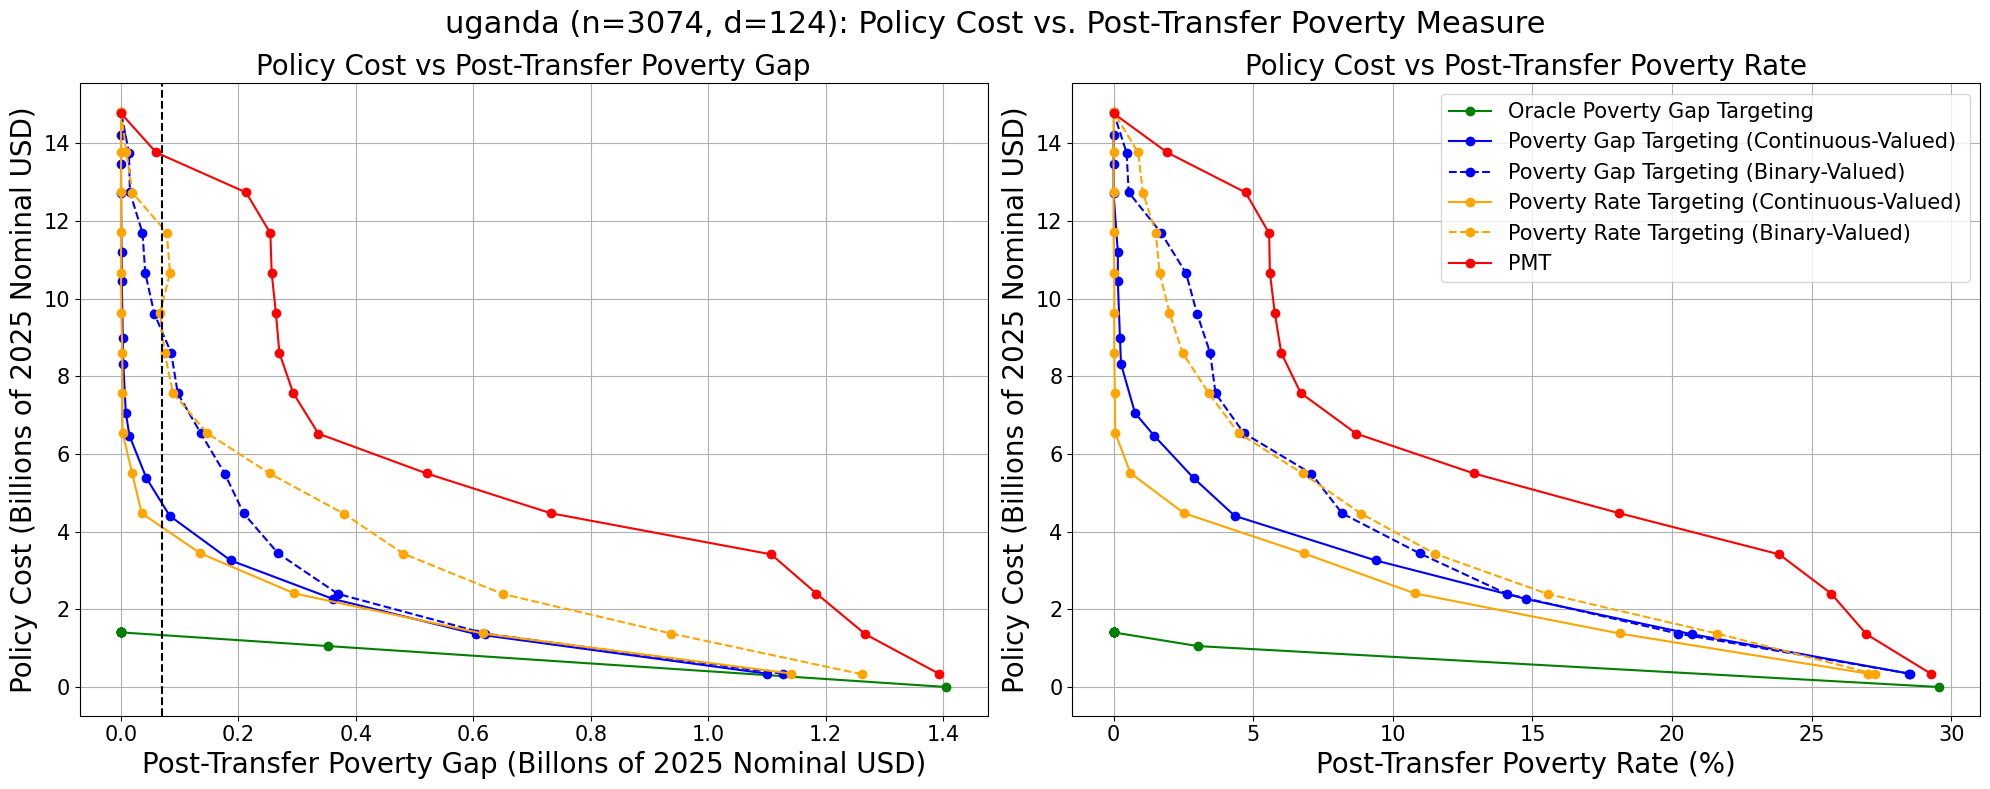

In [34]:
make_plot_for_country("uganda")

oracle_gap 1.6843541111163887
continuous_gap 3.518257986472422
binary_gap 3.7282931160150747
continuous_rate 3.7541070399070007
binary_rate 4.228284842075655
pmt 5.23879766849721


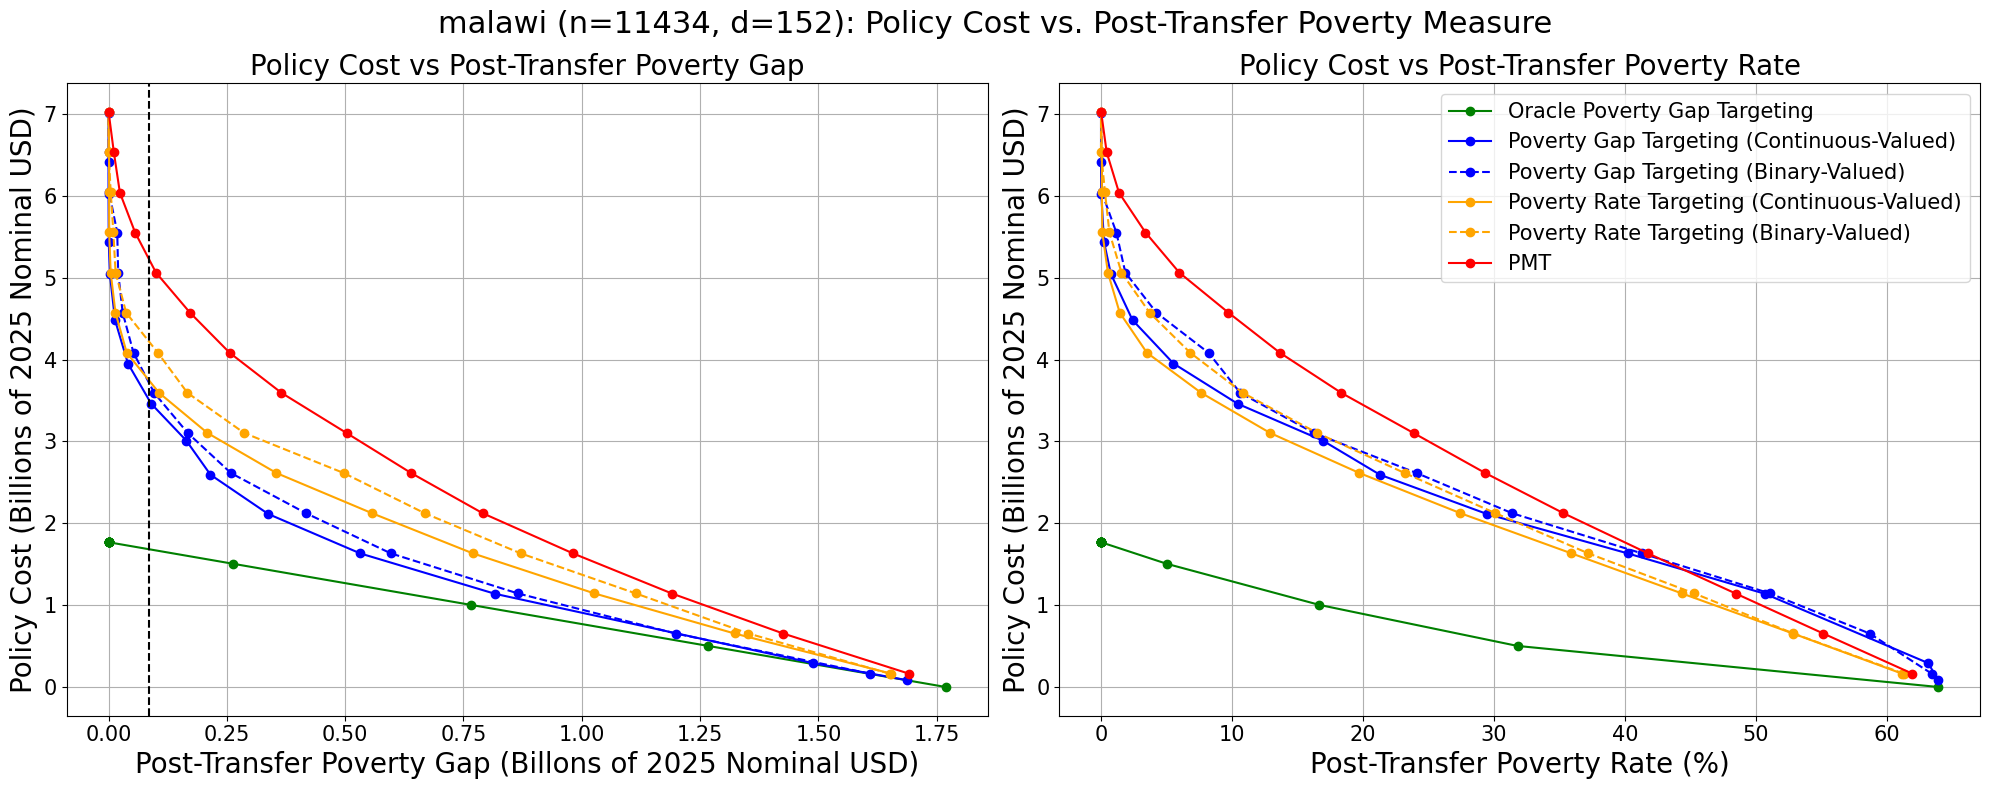

In [35]:
make_plot_for_country('malawi')

oracle_gap 5.159333422992381
continuous_gap 17.926073199164108
binary_gap 21.166811350028578
continuous_rate 22.194280546300966
binary_rate 20.653594391669348
pmt 30.421246178378677


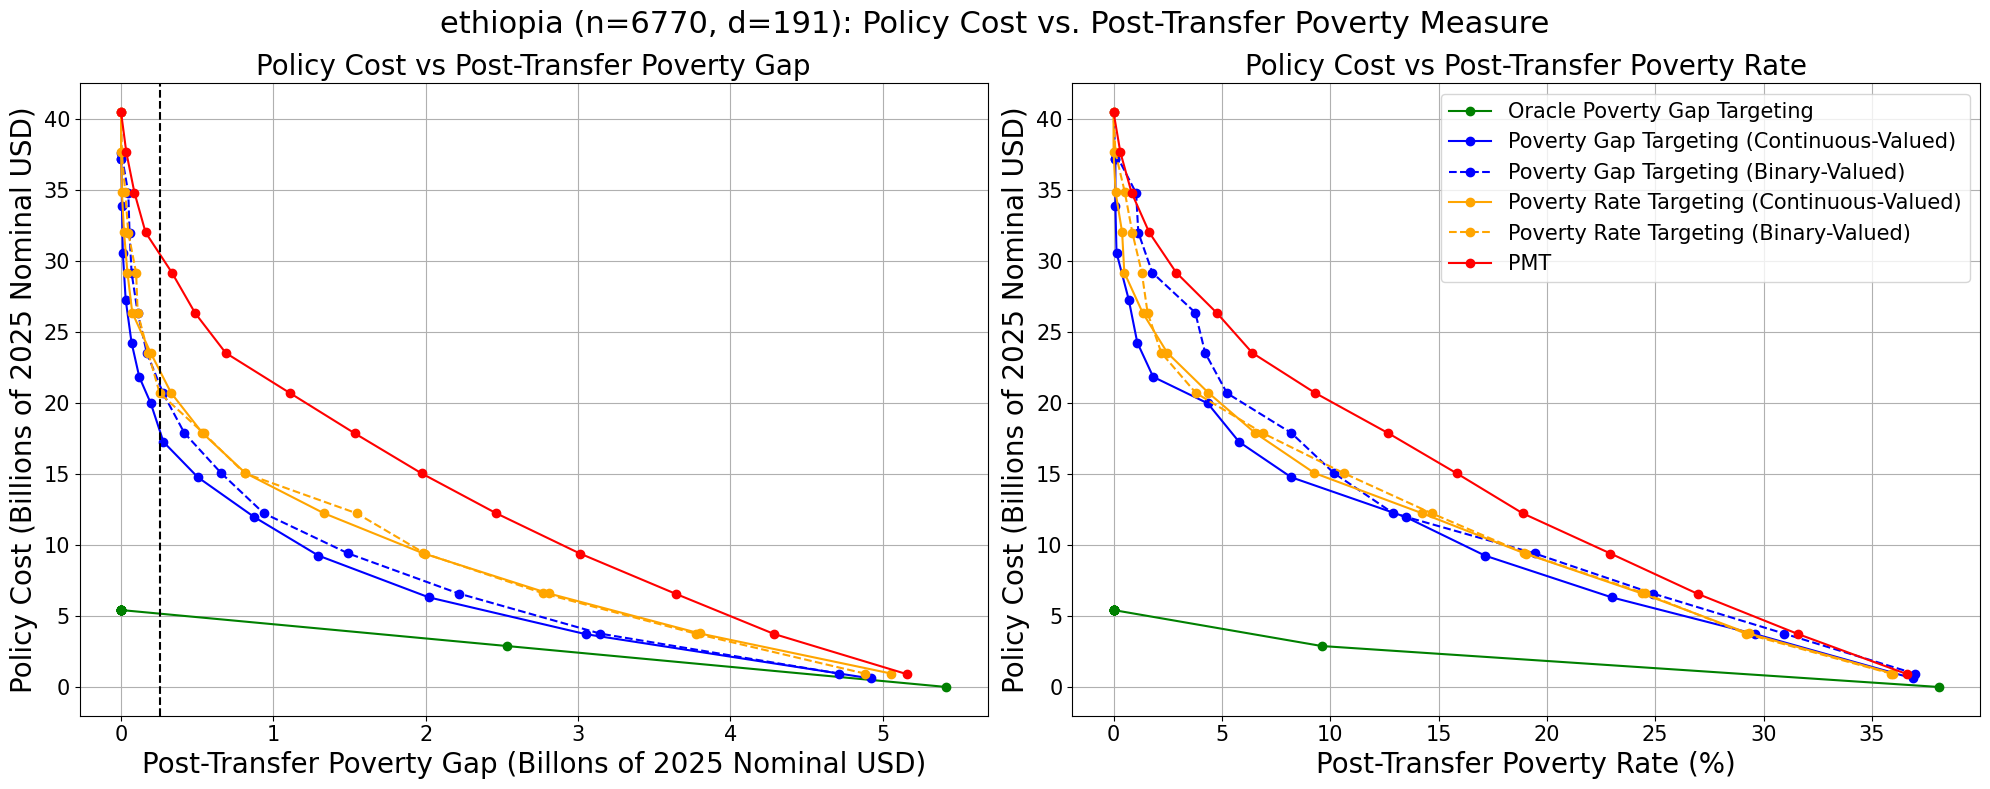

In [36]:
make_plot_for_country("ethiopia")

oracle_gap 0.14283925194122876
continuous_gap 0.7931233508611137
binary_gap 1.2459833633664987
continuous_rate 1.0854814956978407
binary_rate 1.362875552434895
pmt 2.083786027282132


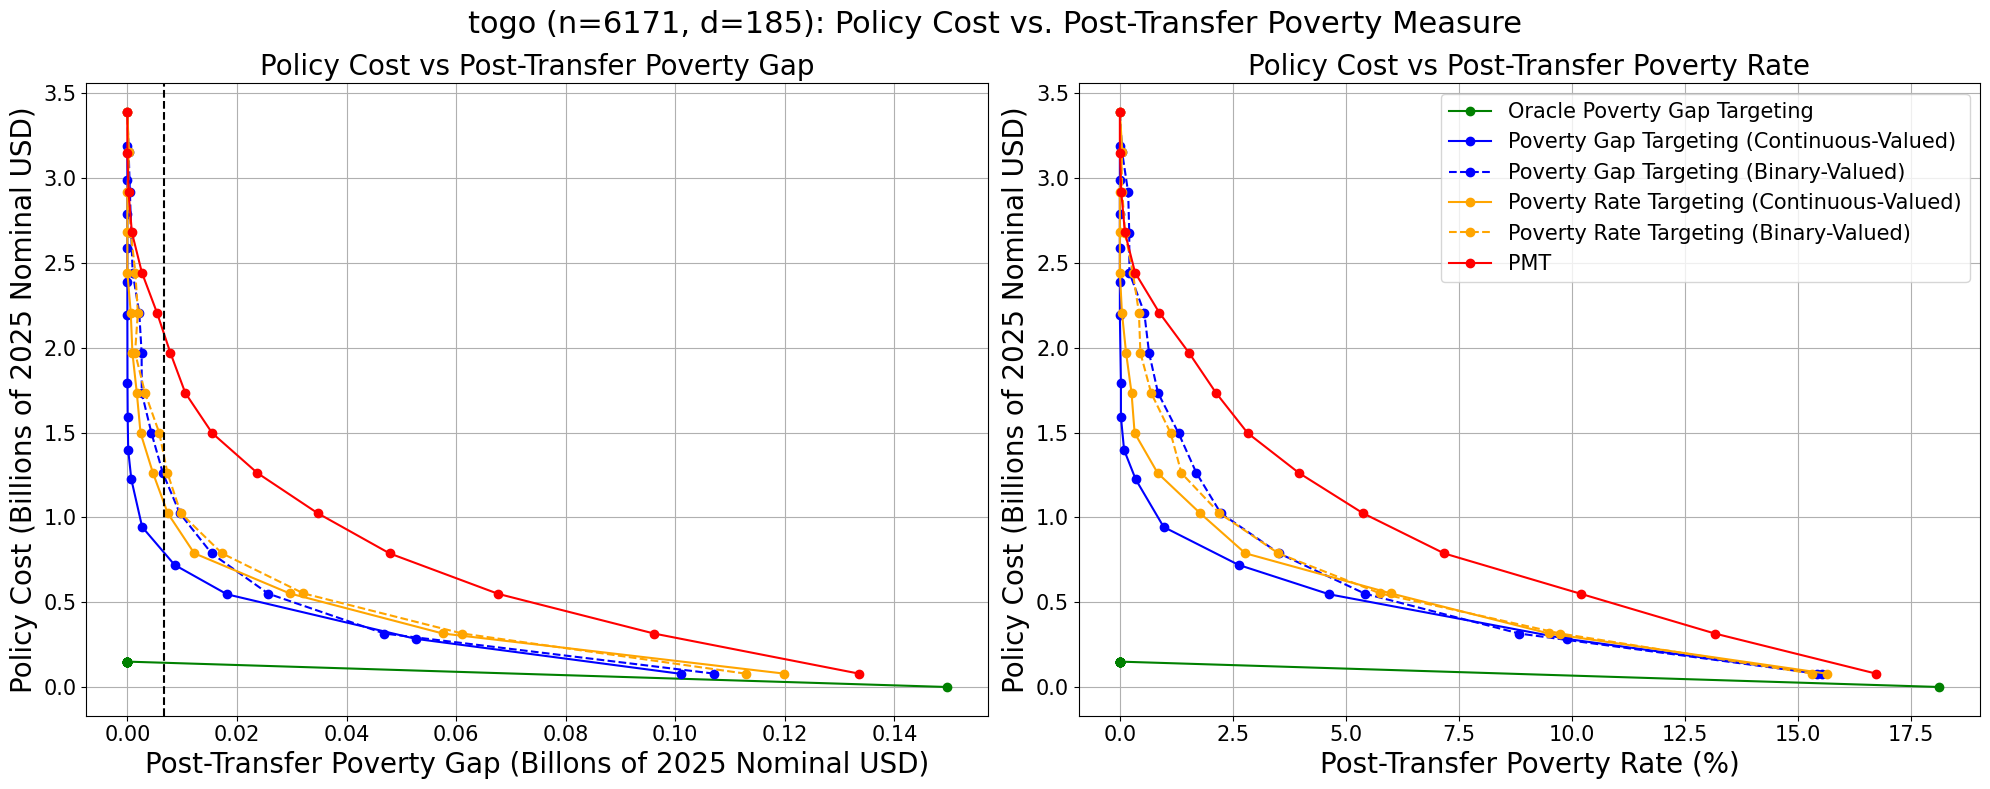

In [37]:
make_plot_for_country("togo")

oracle_gap 0.1147270561544495
continuous_gap 0.5460302205618464
binary_gap 0.9982651497698402
continuous_rate 0.6190278885480256
binary_rate 0.7726168878002873
pmt 1.258698179849133


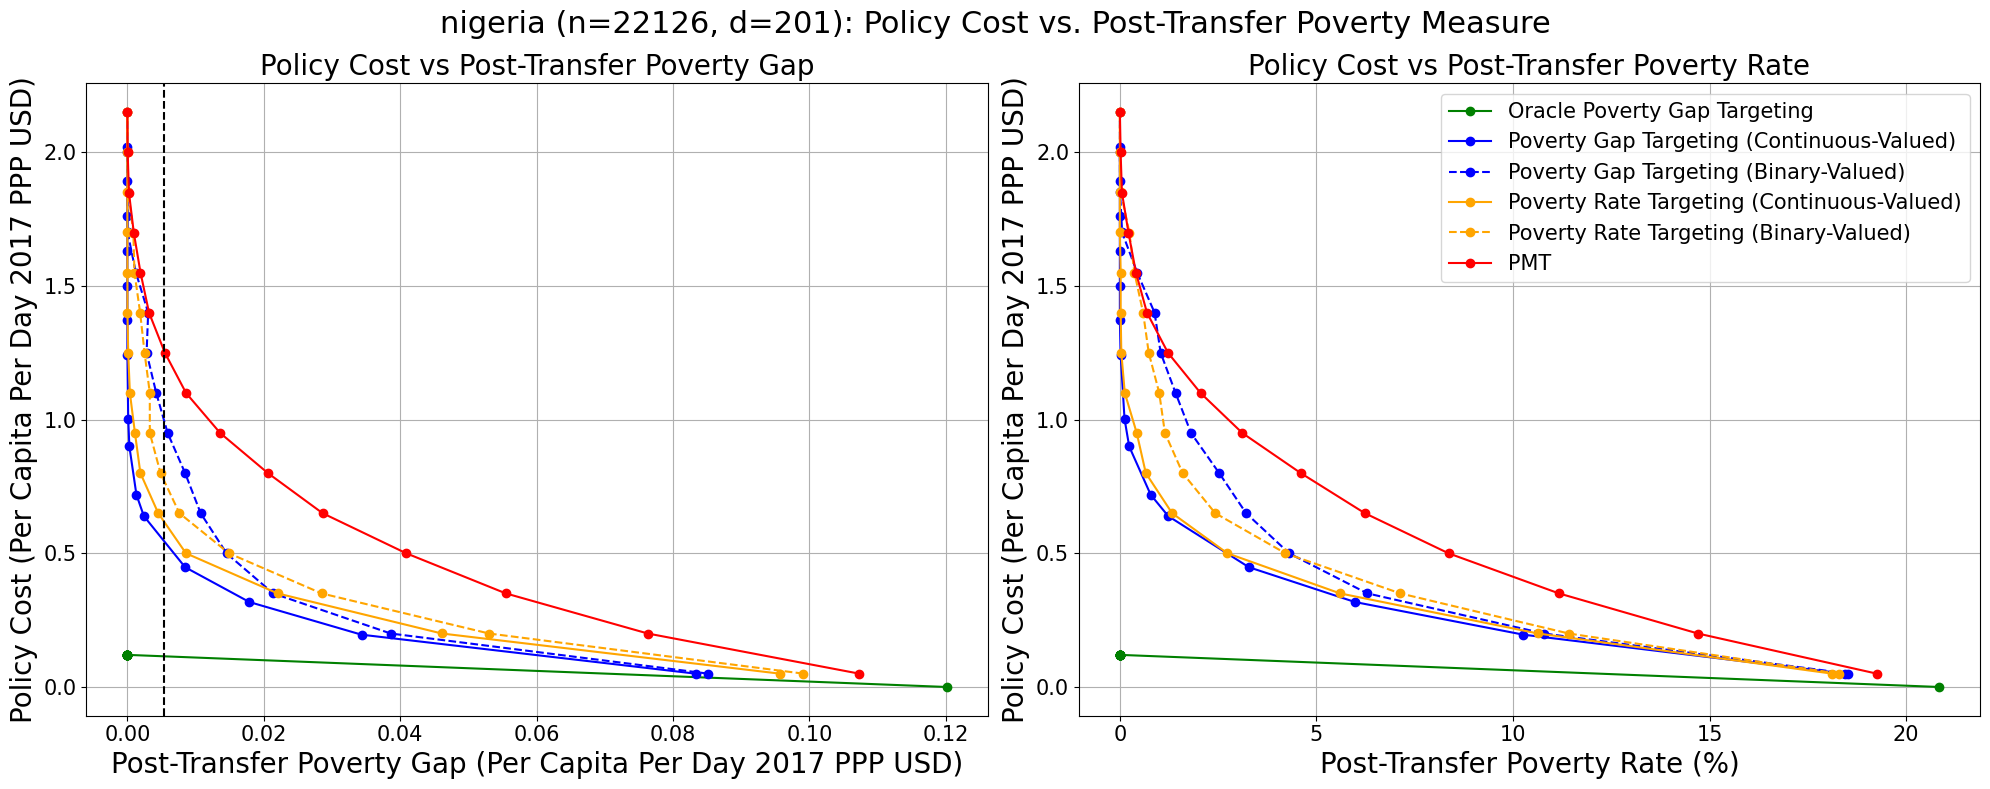

In [32]:
make_plot_for_country("nigeria")